# Porto Seguro’s Safe Driver Prediction

## 0. Загрузка данных

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [9]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (595212, 59)
Test shape: (892816, 58)


**Скопировал из каггла:**

Описание данных  
В этом соревновании вам предстоит предсказать вероятность того, что владелец полиса автострахования подаст заявление о возмещении ущерба. 

В обучающих и тестовых данных признаки, относящиеся к схожим группам, помечены соответствующим образом в названиях признаков (например, ind, reg, car, calc).  Кроме того, в названиях признаков используется постфикс bin для обозначения бинарных признаков и cat для обозначения категориальных признаков.  Признаки без этих обозначений являются либо непрерывными, либо порядковыми.  Значения -1 указывают на то, что признак отсутствовал в наблюдении.  Целевые столбцы показывают, подавал ли владелец полиса заявление о возмещении ущерба.

## 1. EDA

### 1.1. Начальный осмотр данных

In [6]:
train.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [8]:
train.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 1.2. Распределение таргета

In [9]:
# Распределение классов
target_counts = train['target'].value_counts()
target_pct = train['target'].value_counts(normalize=True) * 100

In [10]:
print(f"Класс 0 (Нет страхового случая): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Класс 1 (Есть страховой случай):  {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"Дисбаланс: {target_pct[0]/target_pct[1]:.2f}:1")

Класс 0 (Нет страхового случая): 573,518 (96.36%)
Класс 1 (Есть страховой случай):  21,694 (3.64%)
Дисбаланс: 26.44:1


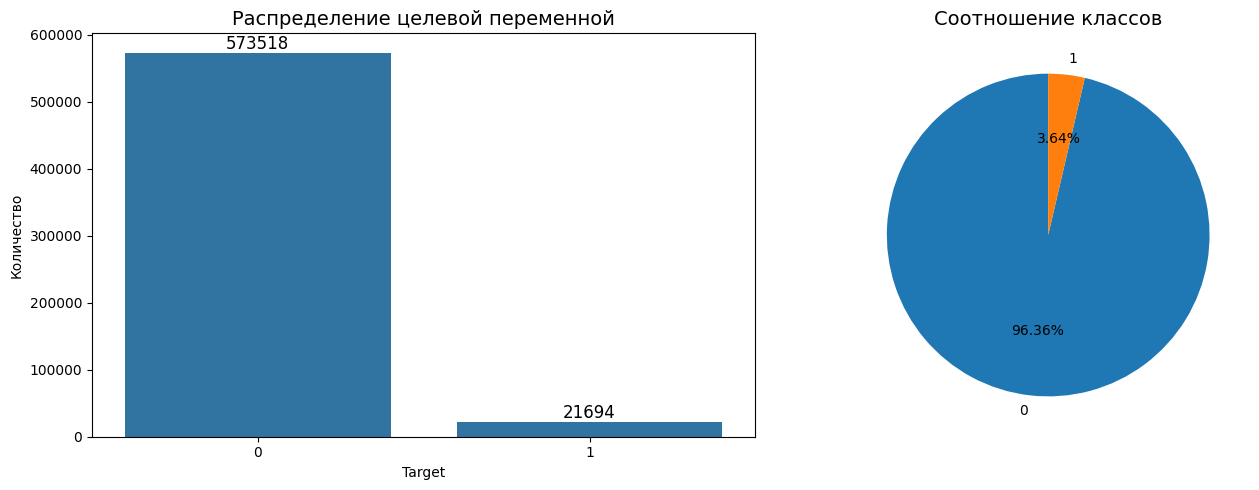

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train, x='target', ax=axes[0])
axes[0].set_title('Распределение целевой переменной', fontsize=14)
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Количество')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

train['target'].value_counts(normalize=True).plot(kind='pie', autopct='%1.2f%%', 
                                                   startangle=90, ax=axes[1])
axes[1].set_title('Соотношение классов', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 1.3. Пропуски

In [15]:
# Пропуски в train
missing_train = train.isnull().sum().sum()
missing_train

0

In [16]:
# Пропуски в test
missing_test = test.isnull().sum().sum()
missing_test

0

### 1.4. Закодированные пропуски

In [22]:
print("Признаки, содержащие -1 (закодированные пропуски):")
cols_with_minus1 = []
for col in train.columns:
    if col != 'id' and col != 'target':
        if (train[col] == -1).any():
            cols_with_minus1.append(col)
            count = (train[col] == -1).sum()
            pct = count / len(train) * 100
            print(f"  {col}: {count:,} ({pct:.2f}%)")

print(f"Всего признаков с -1: {len(cols_with_minus1)}")

Признаки, содержащие -1 (закодированные пропуски):
  ps_ind_02_cat: 216 (0.04%)
  ps_ind_04_cat: 83 (0.01%)
  ps_ind_05_cat: 5,809 (0.98%)
  ps_reg_03: 107,772 (18.11%)
  ps_car_01_cat: 107 (0.02%)
  ps_car_02_cat: 5 (0.00%)
  ps_car_03_cat: 411,231 (69.09%)
  ps_car_05_cat: 266,551 (44.78%)
  ps_car_07_cat: 11,489 (1.93%)
  ps_car_09_cat: 569 (0.10%)
  ps_car_11: 5 (0.00%)
  ps_car_12: 1 (0.00%)
  ps_car_14: 42,620 (7.16%)
Всего признаков с -1: 13


### 1.5. Распределения числовых колонок

In [16]:
id_col = 'id'
target_col = 'target'

binary_cols = [
    'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin',
    'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin',
    'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin',
    'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 
    'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin'
]

cat_cols = [
    'ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat',
    'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 
    'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
    'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat',
    'ps_car_10_cat', 'ps_car_11_cat'
]

numeric_cols = [
    'ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15',
    'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
    'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15',
    'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
    'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08',
    'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12',
    'ps_calc_13', 'ps_calc_14'
]

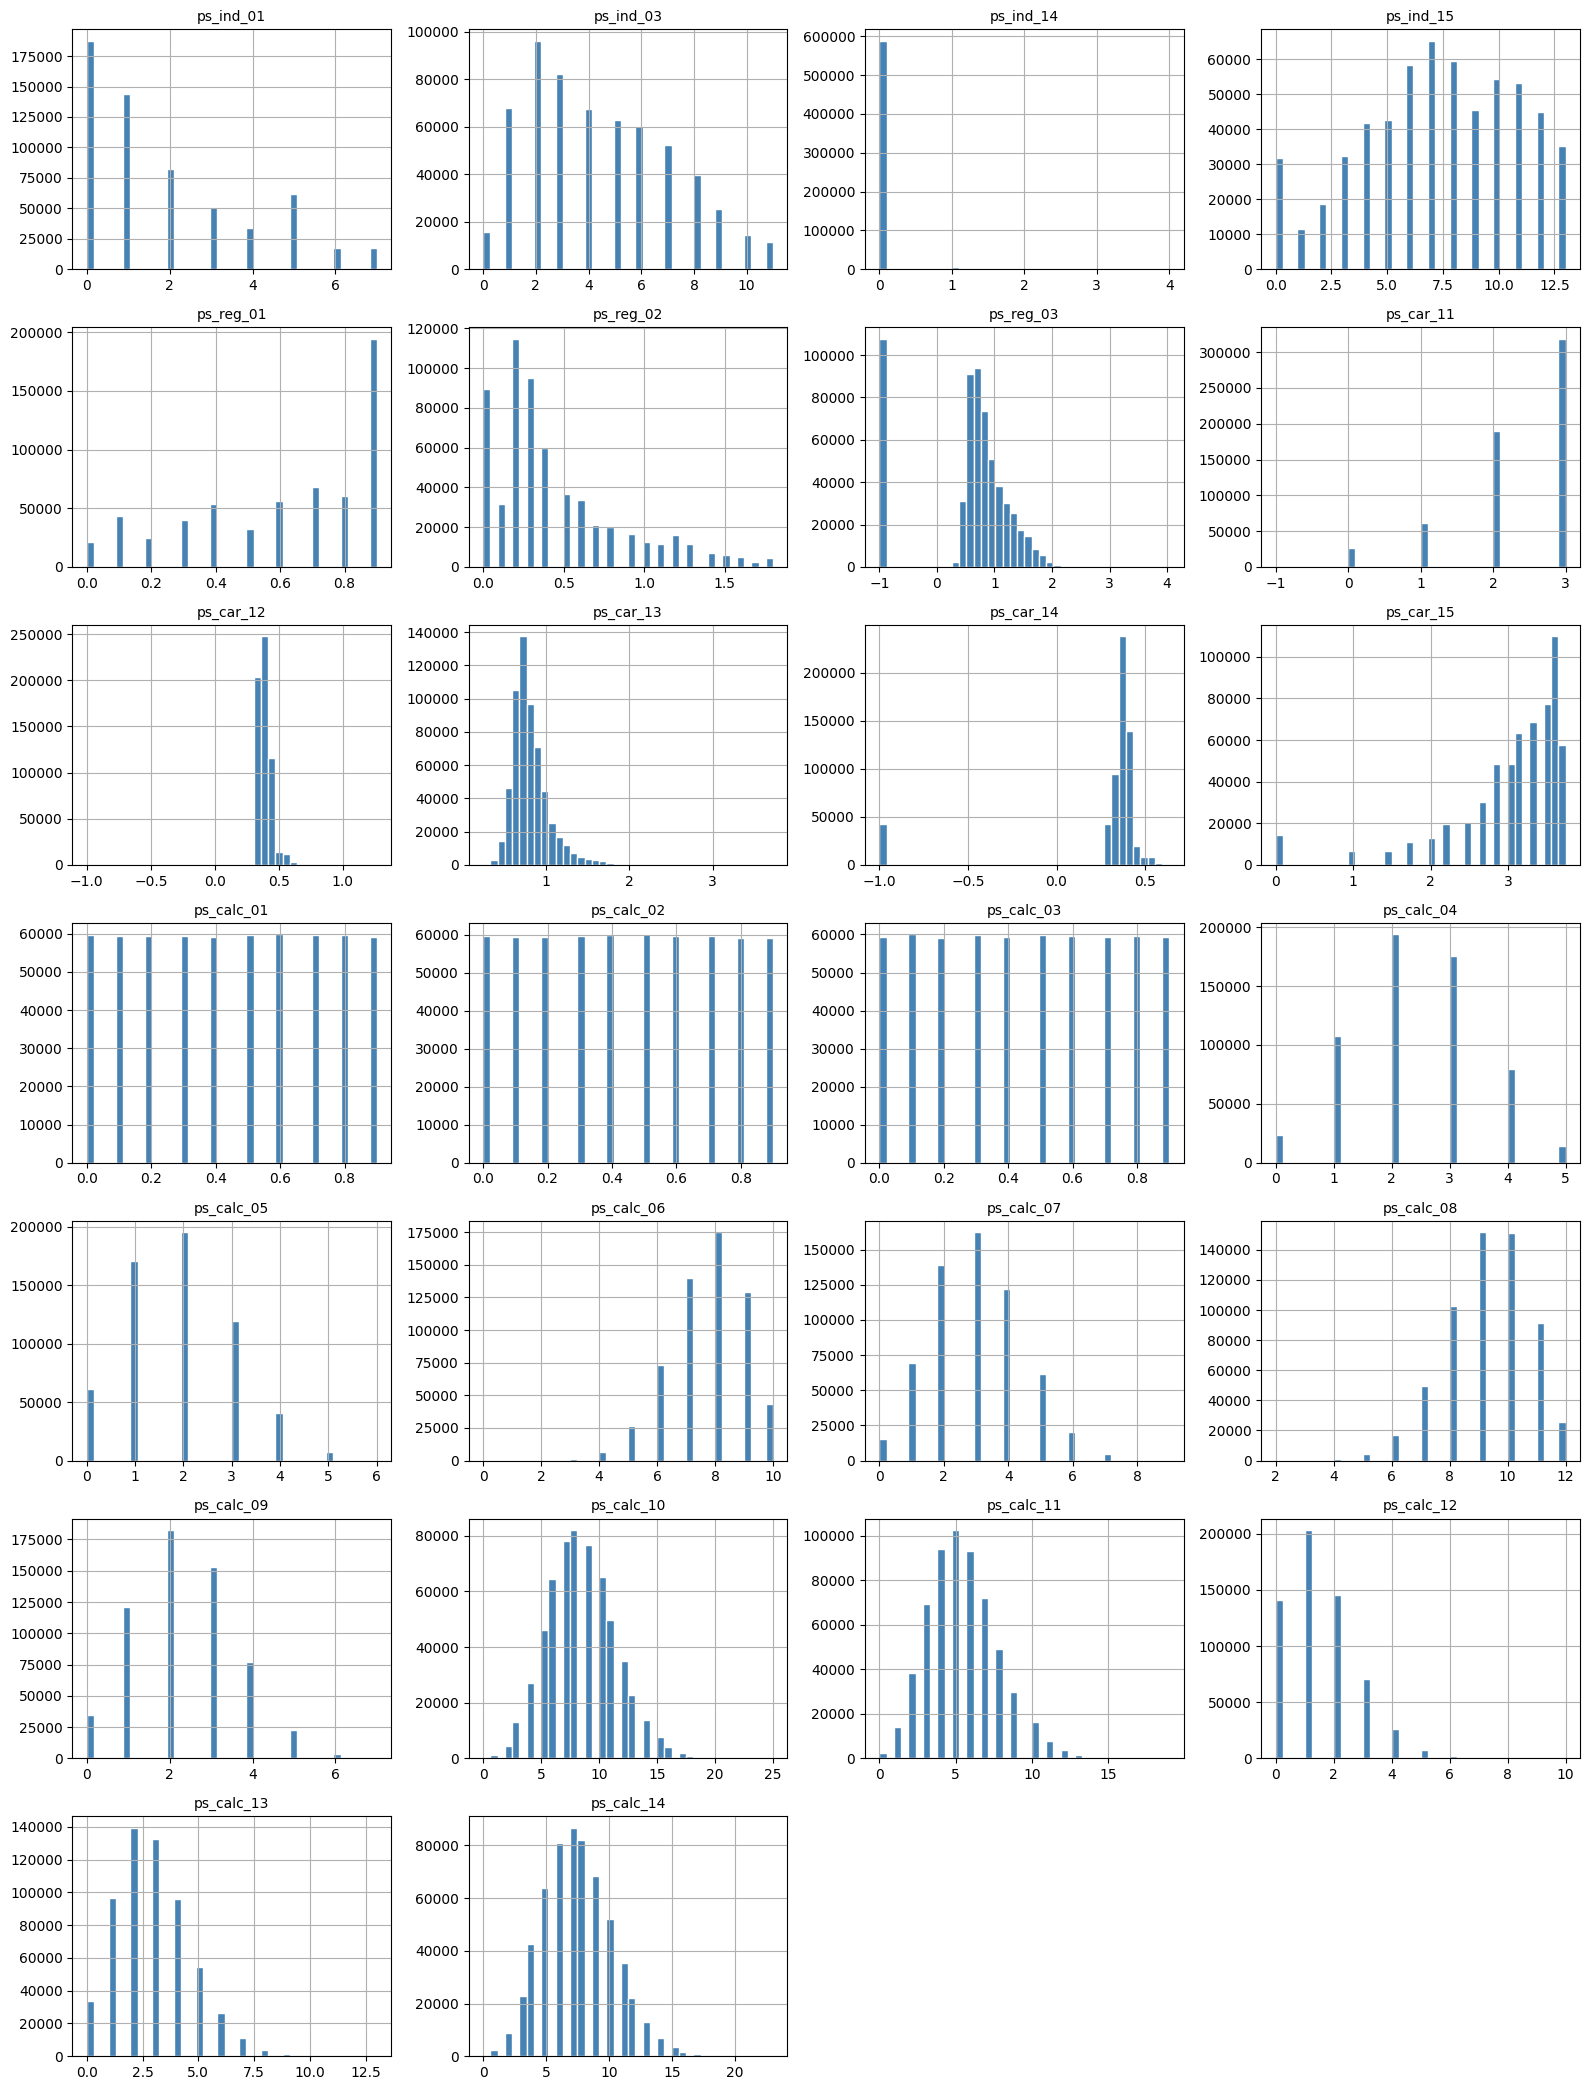

In [30]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    train[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 1.6. Корреляция признаков

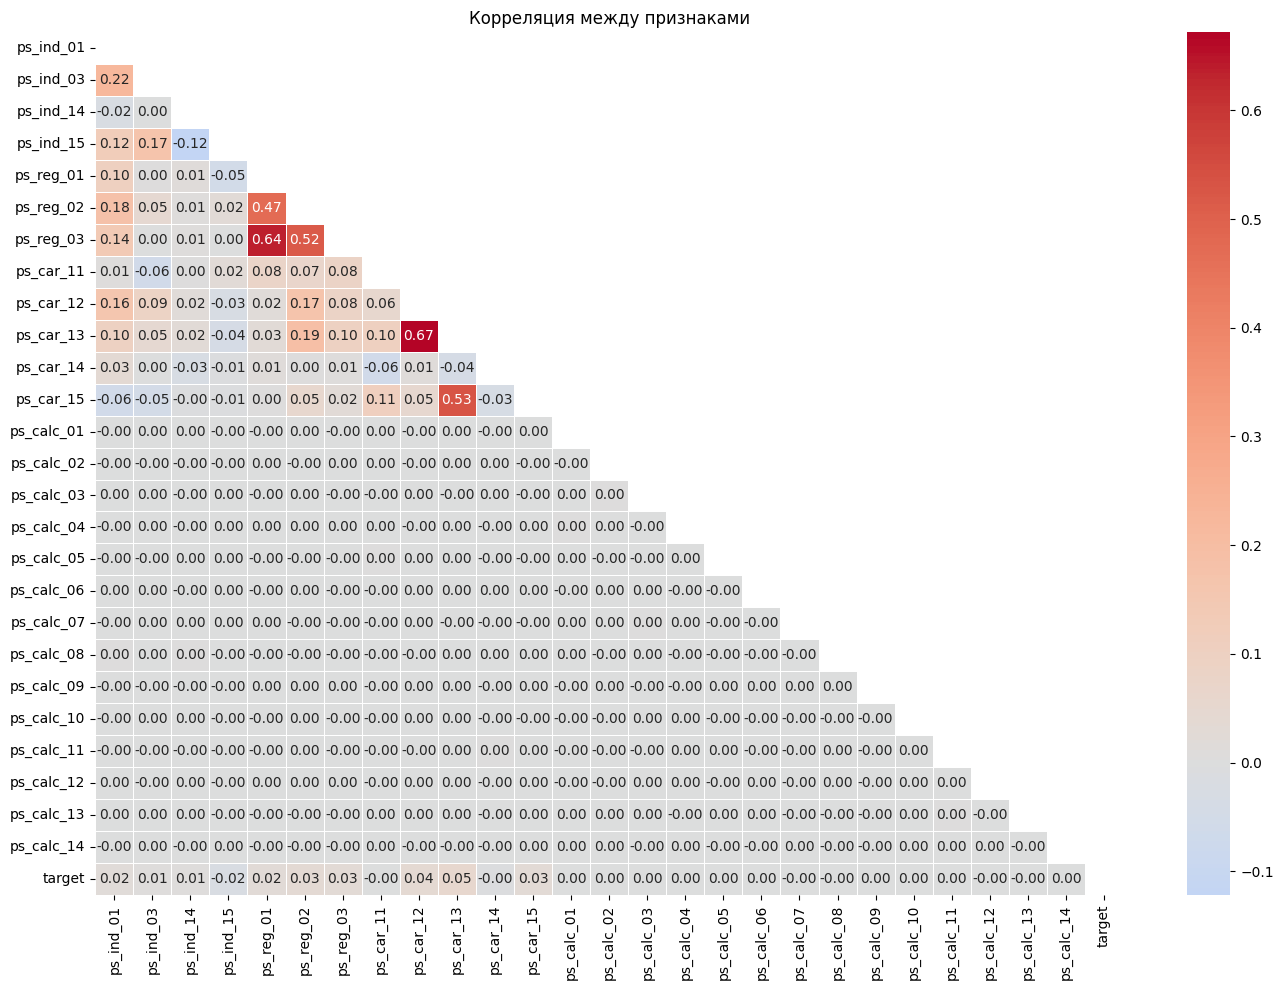

In [36]:
plt.figure(figsize=(14, 10))
corr = train[numeric_cols + [target_col]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [39]:
corr_dict = train[numeric_cols + [target_col]].corr().to_dict()

In [40]:
target_corr = {}
for key in corr_dict.keys():
    if key != 'target':
        target_corr[key] = corr_dict[key]['target']

# Сортируем
sorted_corr = sorted(target_corr.items(), key=lambda x: abs(x[1]), reverse=True)

In [42]:
print("Топ признаков по корреляции с target")
for feature, corr in sorted_corr[:10]:
    print(f"  {feature}: {corr:.6f}")

Топ признаков по корреляции с target
  ps_car_13: 0.053899
  ps_car_12: 0.038790
  ps_reg_02: 0.034800
  ps_reg_03: 0.030888
  ps_car_15: 0.027667
  ps_reg_01: 0.022888
  ps_ind_15: -0.021506
  ps_ind_01: 0.018570
  ps_ind_03: 0.008360
  ps_ind_14: 0.007443


In [43]:
print("Топ признаков с отрицательной корреляцией")
negative = [(f, c) for f, c in sorted_corr if c < 0][:10]
for feature, corr in negative:
    print(f"  {feature}: {corr:.6f}")

Топ признаков с отрицательной корреляцией
  ps_ind_15: -0.021506
  ps_car_14: -0.004474
  ps_car_11: -0.001213
  ps_calc_12: -0.001133
  ps_calc_08: -0.001006
  ps_calc_13: -0.000446
  ps_calc_07: -0.000103


## 2. Обучение baseline

### 2.1. Разделение на X и y

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.preprocessing import LabelEncoder

In [86]:
SEED = 42

In [87]:
test_ids = test['id'].values

In [88]:
X_train = train.copy()
y_train = X_train['target']
X_train = X_train.drop(columns=['id', 'target'])

In [89]:
X_test = test.copy()
X_test = X_test.drop(columns=['id'])

### 2.2. One-hot кодирование категориальных данных

In [94]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [95]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (595212, 215)
Test shape: (892816, 215)


### 2.3. Функция целевой метрики

In [19]:
def gini(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    n = len(actual)
    a_s = actual[np.argsort(pred)]
    a_c = a_s.cumsum()
    gini_sum = a_c.sum() / a_s.sum() - (n + 1) / 2.0
    return gini_sum / n

def gini_normalized(actual, pred):
    return gini(actual, pred) / gini(actual, actual)

Gini измеряет качество ранжирования - насколько хорошо модель ставит "плохих" клиентов (target=1) выше "хороших" (target=0).   
Это главная метрика соревнования.

### 2.4. Gini RandomForest на кросвалидации

In [53]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced'
)


Почему RF: Простая, быстрая модель, устойчивая к переобучению. Даёт базовую точку отсчёта для дальнейших улучшений.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [55]:
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf.fit(X_tr, y_tr)
    pred = rf.predict_proba(X_val)[:, 1]
    score = gini_normalized(y_val, pred)
    cv_scores.append(score)
    print(f"Фолд {fold+1}: {score:.6f}")

print(f"\nCV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

  Fold 1: 0.210001
  Fold 2: 0.201648
  Fold 3: 0.192639
  Fold 4: 0.212304
  Fold 5: 0.186292

CV Gini: 0.200577 (+/- 0.009945)


(+/- 0.009945) - результат, что нет переобучения

### 2.5. Обучение RandomForest

In [56]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 2.6. Предсказание теста

In [57]:
pred = rf.predict_proba(X_test)[:, 1]

In [58]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': pred
})

### 2.7. Первый сабмит и результат

In [59]:
submission.to_csv('rf_baseline.csv', index=False)

Результат:
- 0.19 score на публичном борде

## 3. Добавление колонок Missing

В данных много пропусков, закодированных как -1. Вместо того чтобы просто заменить их на 0, мы создаём отдельный бинарный признак, который говорит модели: "здесь было пропущено значение".

In [90]:
cols_with_minus1 = ["ps_reg_03", "ps_car_14"]

In [91]:
for col in cols_with_minus1:
    X_train[f'{col}_is_missing'] = (X_train[col] == -1).astype(int)
    X_test[f'{col}_is_missing'] = (X_test[col] == -1).astype(int)

In [92]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (595212, 59)
Test shape: (892816, 59)


In [ ]:
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf.fit(X_tr, y_tr)
    pred = rf.predict_proba(X_val)[:, 1]
    score = gini_normalized(y_val, pred)
    cv_scores.append(score)
    print(f"Фолд {fold+1}: {score:.6f}")

print(f"\nCV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

CV mean score = 0.205

## 4. LightGBM

Переход на бустинг

### 4.1. Параметры бустинга

In [20]:
import lightgbm as lgb

In [21]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'scale_pos_weight': 5,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

### 4.2. Кроссвалидация

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [143]:
cv_scores = []
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

In [144]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Создаем dataset
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val)
    
    # Обучаем
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(0)
        ]
    )
    
    # Предсказания на валидации
    pred_val = model.predict(X_val, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = pred_val
    
    # Считаем Gini
    score = gini_normalized(y_val, pred_val)
    cv_scores.append(score)
    print(f"Gini: {score:.6f}")
    
    # Предсказания на тесте
    pred_test = model.predict(X_test, num_iteration=model.best_iteration)
    test_predictions += pred_test / 5

print(f"CV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

Фолд 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156806	valid_1's binary_logloss: 0.156971
Gini: 0.219968
Фолд 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156789	valid_1's binary_logloss: 0.15704
Gini: 0.211688
Фолд 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156795	valid_1's binary_logloss: 0.157022
Gini: 0.217798
Фолд 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156791	valid_1's binary_logloss: 0.156986
Gini: 0.216071
Фолд 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156706	valid_1's binary_logloss: 0.157143
Gini: 0.204999
CV Gini: 0.214105 (+/- 0.0

Данные разбиваются на 5 частей
На каждом фолде:
- Обучаем модель на 4 частях
- Предсказываем на 1 части (валидация) - сохраняем в oof_predictions
- Предсказываем на тесте - сохраняем в test_predictions

В конце усредняем 5 тестовых предсказаний (test_predictions / 5) - это один из ключевых идей для улучшения результата

Каждая из 5 моделей видит разные данные и даёт немного разные предсказания. Усреднение снижает дисперсию и делает предсказания более стабильными.

### 4.3. Сабмит на основе предсказаний при кроссвалидации на тестовой выборке

In [145]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': test_predictions
})
submission.to_csv('lgbm2.csv', index=False)

Результат:
- 0.23 score

Почему выросло:
- LightGBM - более мощный алгоритм
- Индикаторы пропусков дали дополнительную информацию
- Усреднение по 5 фолдам сделало предсказания стабильнее

## 5. Подбор параметров LightGBM

### 5.1. Функция кроссвалидации

In [273]:
def run_lgb_cv(X, y, params, n_folds=5, num_boost_round=1000, early_stopping=50, random_state=42):
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        print(f"Фолд {fold+1}/{n_folds}")
        
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.train(
            params,
            lgb.Dataset(X_tr, label=y_tr),
            num_boost_round=num_boost_round,
            valid_sets=[lgb.Dataset(X_val, label=y_val)],
            callbacks=[lgb.early_stopping(early_stopping), lgb.log_evaluation(0)]
        )
        
        pred_val = model.predict(X_val, num_iteration=model.best_iteration)
        
        score = gini_normalized(y_val, pred_val)
        cv_scores.append(score)
        print(f"Gini: {score:.6f}")
    
    print(f"CV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

### 5.2. Сетка параметров

In [195]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

In [203]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'random_state': SEED,
    'n_jobs': -1,
    'subsample': 0.5,
    'verbose': -1
}

In [204]:
param_grid = {
    'num_leaves': [31, 63, 127],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'reg_alpha': [0.1, 1, 3],
    'reg_lambda': [0.1, 1, 3],
    'scale_pos_weight': [1, 3, 5]
}

### 5.3. Поиск параметров

In [205]:
random_search = RandomizedSearchCV(
    lgb.LGBMClassifier(**params),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring=make_scorer(gini_normalized),
    random_state=SEED,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший CV Gini: {random_search.best_score_:.6f}")

In [213]:
best_params = {
    'num_leaves': 63,
    'max_depth': 8,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': 1,
}

### 5.4. Сабмит

In [208]:
best_model = random_search.best_estimator_

In [209]:
pred = best_model.predict_proba(X_test)[:, 1]

In [210]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': pred
})
submission.to_csv('random_search.csv', index=False)

Результат:
-  LB 0.235 - лишь немного улучшили результат lightgbm

## 6. Добавление новых признаков

### 6.1. Параметры модели и данные

In [215]:
params = {
    'num_leaves': 63,
    'max_depth': 8,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': 1,
    'objective': 'binary',
    'metric': 'binary_logloss',
    'scale_pos_weight': 5,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

In [26]:
X_features = X_train.copy(deep=True)

In [27]:
X_test_copy = X_test.copy(deep=True)

### 6.2. Новые признаки и кроссвалидация

In [29]:
X_features['is_new_driver'] = (X_features['ps_ind_03'] < 5).astype(int)  # новичок

In [84]:
run_lgb_cv(X_features, y_train, params, num_boost_round=2000)

Gini: 0.223212
Gini: 0.210965
Gini: 0.217789
Gini: 0.215463
Gini: 0.204612
CV Gini: 0.214408 (+/- 0.006291)


In [30]:
# Квадрат возраста (риск падает после 30, но растет после 60)
X_features['age_squared'] = X_features['ps_ind_01'] ** 2

In [88]:
run_lgb_cv(X_features, y_train, params, num_boost_round=2000)

Gini: 0.223212
Gini: 0.209972
Gini: 0.218001
Gini: 0.215307
Gini: 0.202762
CV Gini: 0.213851 (+/- 0.007000)


> Новички (стаж < 5 лет) попадают в аварии чаще. Бинарный признак помогает модели выделить эту группу.

> Квадрат возраста - риск не линейный: молодые водители рискованны, риск падает к 30-40 годам, затем снова растёт. Квадратичный признак позволяет модели уловить эту U-образную зависимость.

### 6.3. Предсказание теста с новыми признаками

In [150]:
train_data = lgb.Dataset(X_features, label=y_train)

lgbm_model_features = lgb.train(
    params,
    train_data,
    num_boost_round=2000
)

In [151]:
X_test_copy['is_new_driver'] = (X_test_copy['ps_ind_03'] < 5).astype(int)  # новичок
X_test_copy['age_squared'] = X_test_copy['ps_ind_01'] ** 2

In [152]:
cv_scores = []
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

In [153]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_features, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Создаем dataset
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val)
    
    # Обучаем
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(0)
        ]
    )
    
    # Предсказания на валидации
    pred_val = model.predict(X_val, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = pred_val
    
    # Считаем Gini
    score = gini_normalized(y_val, pred_val)
    cv_scores.append(score)
    print(f"Gini: {score:.6f}")
    
    # Предсказания на тесте
    pred_test = model.predict(X_test_copy, num_iteration=model.best_iteration)
    test_predictions += pred_test / 5

print(f"CV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

Фолд 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156806	valid_1's binary_logloss: 0.156971
Gini: 0.219968
Фолд 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156789	valid_1's binary_logloss: 0.15704
Gini: 0.211688
Фолд 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156795	valid_1's binary_logloss: 0.157022
Gini: 0.217798
Фолд 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156791	valid_1's binary_logloss: 0.156986
Gini: 0.216071
Фолд 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's binary_logloss: 0.156706	valid_1's binary_logloss: 0.157143
Gini: 0.204999
CV Gini: 0.214105 (+/- 0.0

### 6.4. Сабмит и результат

In [154]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': test_predictions
})
submission.to_csv('lgbm_with_features.csv', index=False)

Новые признаки никак не повлияли на результат:
- score 0.23

В этом соревновании простые "осмысленные" признаки не работают. Данные уже сильно обработаны и анонимизированы. Нужны либо комбинации признаков, либо генерация тысяч синтетических признаков.

Признаки пока оставим. Вернемся к моделям

## 7. CatBoost

### 7.1. Модель и базовые параметры

In [31]:
from catboost import CatBoostClassifier

In [33]:
params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'scale_pos_weight': 1,
    'random_state': SEED,
    'verbose': -1
}

In [34]:
catboost_model = CatBoostClassifier(**params)

### 7.2. Кроссвалидация

In [171]:
cv_scores = []
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_features, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = CatBoostClassifier(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=False
    )
    
    best_iter = model.get_best_iteration()
    
    pred_val = model.predict_proba(X_val, ntree_end=best_iter)[:, 1]
    oof_predictions[val_idx] = pred_val
    
    score = gini_normalized(y_val, pred_val)
    cv_scores.append(score)
    print(f"Gini: {score:.6f}")
    
    pred_test = model.predict_proba(X_test_copy, ntree_end=best_iter)[:, 1]
    test_predictions += pred_test / 5

print(f"CV Gini: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")

Фолд 1/5
Gini: 0.286646
Фолд 2/5
Gini: 0.278450
Фолд 3/5
Gini: 0.278420
Фолд 4/5
Gini: 0.282871
Фолд 5/5
Gini: 0.269686
CV Gini: 0.279215 (+/- 0.005668)


### 7.3. Сабмит и результат

In [172]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': test_predictions
})
submission.to_csv('catboost.csv', index=False)

Результат:
- 0.277 - почти целевой скор.

Нужно поробовать стэкинг

Что важно: CV и LB совпали. Модель не переобучилась.

## 8. Stacking

Вместо того чтобы выбирать одну лучшую модель, мы объединяем их. Каждая модель "видит" данные по-своему, и их комбинация даёт более стабильный результат

### 8.1. Параметры моделей

In [35]:
from sklearn.linear_model import Ridge

In [41]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [36]:
lgb_params = {
    'num_leaves': 63,
    'max_depth': 8,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': 1,
    'objective': 'binary',
    'metric': 'binary_logloss',
    'scale_pos_weight': 5,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

In [37]:
cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'scale_pos_weight': 1,
    'random_state': SEED,
    'verbose': -1
}

In [38]:
rf_params = {
    'n_estimators': 300,
    'random_state': SEED,
    'n_jobs': -1,
    'class_weight': 'balanced'
}

### 8.2. Кроссвалидация стэкинга

In [61]:
from sklearn.model_selection import cross_val_predict

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [96]:
len(X_test_copy.columns)

27

In [49]:
lgb_oof = np.zeros(len(X_features))
lgb_test = np.zeros(len(X_test))

cat_oof = np.zeros(len(X_features))
cat_test = np.zeros(len(X_test_copy))

rf_oof = np.zeros(len(X_features))
rf_test = np.zeros(len(X_test_copy))

In [50]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_features, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # LightGBM
    model = lgb.train(
        lgb_params,
        lgb.Dataset(X_tr, label=y_tr),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(X_val, label=y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    lgb_oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    lgb_test += model.predict(X_test_copy, num_iteration=model.best_iteration) / 5
    
    # CatBoost
    model = CatBoostClassifier(**cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    best_iter = model.get_best_iteration()
    cat_oof[val_idx] = model.predict_proba(X_val, ntree_end=best_iter)[:, 1]
    cat_test += model.predict_proba(X_test_copy, ntree_end=best_iter)[:, 1] / 5
    
    # Random Forest
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)
    rf_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    rf_test += model.predict_proba(X_test_copy)[:, 1] / 5

Фолд 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155859
Фолд 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155891
Фолд 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155825
Фолд 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.15585
Фолд 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155909


### 8.4. Gini по кроссвалидации

Считаем gini через кроссвалидацию

In [55]:
meta_X_train = np.column_stack([lgb_oof, cat_oof, rf_oof])
meta_X_test = np.column_stack([lgb_test, cat_test, rf_test])

In [53]:
ridge = Ridge(alpha=1.0)

In [62]:
meta_preds = cross_val_predict(
    ridge, 
    meta_X_train, 
    y_train, 
    cv=5,
    method='predict'
)

In [63]:
print(f"CV Gini: {gini_normalized(y_train, meta_preds):.4f}")

CV Gini: 0.2783


### 8.5. Обучение мета модели

In [64]:
ridge.fit(meta_X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 8.6. Предсказание теста и сабмит

In [194]:
stacking_pred = ridge.predict(meta_X_test)

In [195]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': stacking_pred
})

In [196]:
submission.to_csv('stacking.csv', index=False)

Результат:
- 0.278 - чуть лучше обычного catboost

## 9. Добавление признака аномалии и удаление ненужных колонок

Добавил признак "аномалия" - является ли клиент непохожим на других. Аномалии могут быть связаны со страховыми случаями.

Isolation Forest случайно "разрезает" данные. Аномалии изолируются быстрее, чем обычные точки.

### 9.1. Удаление ненужных колонок

In [65]:
from sklearn.ensemble import IsolationForest

In [66]:
X_features = X_train.copy(deep=True)
X_test_copy = X_test.copy(deep=True)

In [67]:
drop_cols = [
    'ps_ind_14',
    'ps_car_14',
    'ps_ind_10_bin',
    'ps_ind_11_bin',
    'ps_ind_12_bin',
    'ps_ind_13_bin',
    'ps_car_11',
    'ps_car_12',
]

Признаки удалены по результатам экспериментов: их исключение на чуть-чуть улучшало кросс-валидацию. Основные причины - высокая корреляция с другими признаками, большое количество пропусков и отсутствие вклада в качество модели.

In [68]:
X_features = X_features.drop(columns=drop_cols)
X_test_copy = X_test_copy.drop(columns=drop_cols)

### 9.2. Признак аномалии

In [69]:
iso = IsolationForest(contamination=0.1, random_state=42)
X_features['anomaly_score'] = iso.fit_predict(X_features)
X_test_copy['anomaly_score'] = iso.predict(X_test_copy)

In [70]:
# IsolationForest возвращает 1 для нормальных, -1 для аномалий
X_features['anomaly_score'] = (X_features['anomaly_score'] == -1).astype(int)
X_test_copy['anomaly_score'] = (X_test_copy['anomaly_score'] == -1).astype(int)

### 9.3. Кроссвалидация

In [71]:
params = {
    'num_leaves': 63,
    'max_depth': 8,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': 1,
    'objective': 'binary',
    'metric': 'binary_logloss',
    'scale_pos_weight': 5,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

In [72]:
lgb_oof = np.zeros(len(X_features))
lgb_test = np.zeros(len(X_test))

cat_oof = np.zeros(len(X_features))
cat_test = np.zeros(len(X_test_copy))

rf_oof = np.zeros(len(X_features))
rf_test = np.zeros(len(X_test_copy))

In [73]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_features, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # LightGBM
    model = lgb.train(
        lgb_params,
        lgb.Dataset(X_tr, label=y_tr),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(X_val, label=y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    lgb_oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    lgb_test += model.predict(X_test_copy, num_iteration=model.best_iteration) / 5
    
    # CatBoost
    model = CatBoostClassifier(**cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    best_iter = model.get_best_iteration()
    cat_oof[val_idx] = model.predict_proba(X_val, ntree_end=best_iter)[:, 1]
    cat_test += model.predict_proba(X_test_copy, ntree_end=best_iter)[:, 1] / 5
    
    # Random Forest
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)
    rf_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    rf_test += model.predict_proba(X_test_copy)[:, 1] / 5

Фолд 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.15586
Фолд 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155904
Фолд 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155825
Фолд 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155841
Фолд 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.155916


### 9.4. Джини по кроссвалидации

In [74]:
meta_X_train = np.column_stack([lgb_oof, cat_oof, rf_oof])
meta_X_test = np.column_stack([lgb_test, cat_test, rf_test])

In [75]:
ridge = Ridge(alpha=1.0)

In [76]:
meta_preds = cross_val_predict(
    ridge, 
    meta_X_train, 
    y_train, 
    cv=5,
    method='predict'
)

In [77]:
print(f"CV Gini: {gini_normalized(y_train, meta_preds):.4f}")

CV Gini: 0.2799


### 9.5. Обучение метамодели

In [78]:
ridge.fit(meta_X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 9.5. Предсказание теста и сабмит

In [216]:
stack_pred = ridge.predict(meta_X_test)

In [217]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': stack_pred
})

In [218]:
submission.to_csv('stacking_improved.csv', index=False)

Результат:
- \+ 0.001 к публичному скору (0.279)

Прирост +0.001. Признак даёт независимую информацию, которую деревья не улавливают.  

## 10. Добавляем xgboost в стэккинг

### 10.1. Удаление ненужных колонок

Из данных были удалены:
- Все `ps_calc_*` - их корреляция с целевой переменной близка к нулю
- `ps_car_03_cat`, `ps_car_05_cat` - более 40% пропусков
- Ещё 8 признаков, которые ухудшали качество по результатам экспериментов

Удаление этих признаков - идея топ решений

In [79]:
X_features = train.drop(columns=['id', 'target'])
y_train = train['target']
X_test_copy = test.drop(columns=['id'])

In [80]:
drop_cols = [
    'ps_ind_14',
    'ps_car_14',
    'ps_ind_10_bin',
    'ps_ind_11_bin',
    'ps_ind_12_bin',
    'ps_ind_13_bin',
    'ps_car_11',
    'ps_car_12',
    'ps_car_03_cat',
    'ps_car_05_cat',
]

In [81]:
X_features = X_features.drop(columns=drop_cols, errors='ignore')
X_test_copy = X_test_copy.drop(columns=drop_cols, errors='ignore')

In [82]:
calc_cols = [col for col in X_features.columns if col.startswith('ps_calc_')]
X_features = X_features.drop(columns=calc_cols)
X_test_copy = X_test_copy.drop(columns=calc_cols)

In [102]:
print(f"  После удаления: {X_features.shape} признаков")

  После удаления: (595212, 215) признаков


### 10.2. Признак аномалии

In [104]:
iso = IsolationForest(contamination=0.1, random_state=42)
X_features['anomaly_score'] = iso.fit_predict(X_features)
X_test_copy['anomaly_score'] = iso.predict(X_test_copy)
X_features['anomaly_score'] = (X_features['anomaly_score'] == -1).astype(int)
X_test_copy['anomaly_score'] = (X_test_copy['anomaly_score'] == -1).astype(int)

In [105]:
# One-Hot для категориальных
cat_cols = [col for col in X_features.columns if '_cat' in col]
X_features = pd.get_dummies(X_features, columns=cat_cols, drop_first=True)
X_test_copy = pd.get_dummies(X_test_copy, columns=cat_cols, drop_first=True)

In [106]:
print(f"Train: {X_features.shape}, Test: {X_test_copy.shape}")

Train: (595212, 216), Test: (892816, 216)


### 10.3. Параметры для моделей

In [112]:
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 63,
    'max_depth': 8,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': 1,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_child_samples': 50,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

In [113]:
cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'iterations': 500,
    'scale_pos_weight': 1,
    'random_seed': SEED,
    'verbose': False,
    'thread_count': -1
}

In [114]:
rf_params = {
    'n_estimators': 300,
    'n_jobs': -1,
    'class_weight': 'balanced',
    'random_state': SEED
}

In [115]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'rmse',
    'base_score': y_train.mean(),
    'scale_pos_weight': 3,
    'random_state': SEED
}

### 10.4. Кроссвалидация

In [107]:
def gini(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    n = len(actual)
    a_s = actual[np.argsort(pred)]
    a_c = a_s.cumsum()
    gini_sum = a_c.sum() / a_s.sum() - (n + 1) / 2.0
    return gini_sum / n

def gini_normalized(actual, pred):
    return gini(actual, pred) / gini(actual, actual)

In [108]:
import xgboost as xgb

In [116]:
lgb_oof = np.zeros(len(X_features))
lgb_test = np.zeros(len(X_test_copy))
cat_oof = np.zeros(len(X_features))
cat_test = np.zeros(len(X_test_copy))
rf_oof = np.zeros(len(X_features))
rf_test = np.zeros(len(X_test_copy))
xgb_oof = np.zeros(len(X_features))
xgb_test = np.zeros(len(X_test_copy))

In [117]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [118]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_features, y_train)):
    print(f"Фолд {fold+1}/5")
    
    X_tr, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # LightGBM
    model = lgb.train(
        lgb_params,
        lgb.Dataset(X_tr, label=y_tr),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(X_val, label=y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    lgb_oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    lgb_test += model.predict(X_test_copy, num_iteration=model.best_iteration) / 5
    
    # CatBoost
    model = CatBoostClassifier(**cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    best_iter = model.get_best_iteration()
    cat_oof[val_idx] = model.predict_proba(X_val, ntree_end=best_iter)[:, 1]
    cat_test += model.predict_proba(X_test_copy, ntree_end=best_iter)[:, 1] / 5
    
    # Random Forest
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)
    rf_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    rf_test += model.predict_proba(X_test_copy)[:, 1] / 5
    
    # XGBoost
    model = xgb.train(
        xgb_params,
        xgb.DMatrix(X_tr, label=y_tr),
        num_boost_round=1000,
        evals=[(xgb.DMatrix(X_val, label=y_val), 'eval')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    best_iter = model.best_iteration
    xgb_oof[val_idx] = model.predict(xgb.DMatrix(X_val), iteration_range=(0, best_iter))
    xgb_test += model.predict(xgb.DMatrix(X_test_copy), iteration_range=(0, best_iter)) / 5

Фолд 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[112]	valid_0's binary_logloss: 0.1517
Фолд 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[141]	valid_0's binary_logloss: 0.152046
Фолд 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[119]	valid_0's binary_logloss: 0.151966
Фолд 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	valid_0's binary_logloss: 0.151866
Фолд 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[110]	valid_0's binary_logloss: 0.152403


### 10.5. Gini по кроссвалидации

In [119]:
meta_X_train = np.column_stack([lgb_oof, cat_oof, rf_oof])
meta_X_test = np.column_stack([lgb_test, cat_test, rf_test])

In [120]:
ridge = Ridge(alpha=1.0)

In [121]:
meta_preds = cross_val_predict(
    ridge, 
    meta_X_train, 
    y_train, 
    cv=5,
    method='predict'
)

In [122]:
print(f"CV Gini: {gini_normalized(y_train, meta_preds):.4f}")

CV Gini: 0.2826


### 10.6. Обучение метамодели

In [123]:
ridge.fit(meta_X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 10.7. Предсказание теста и сабмит

In [264]:
stack_pred = ridge.predict(meta_X_test)

In [265]:
submission = pd.DataFrame({
    'id': test_ids,
    'target': stack_pred
})

In [266]:
submission.to_csv('stacking_improved.csv', index=False)

## 11. Итоги

### 1. Baseline - Random Forest

| Модель | Подход | Public LB |
|:---|:---|:---|
| Random Forest | One-Hot Encoding | **0.19** |

Простая модель для получения точки отсчёта.

---

### 2. LightGBM + индикаторы пропусков

| Модель | Подход | Public LB |
|:---|:---|:---|
| LightGBM | Индикаторы `_is_missing`, усреднение по 5 фолдам | **0.23** |

Бустинг сильнее случайного леса. Индикаторы пропусков помогают модели учитывать отсутствие данных.

---

### 3. Подбор параметров LightGBM

| Модель | Подход | CV | Public LB |
|:---|:---|:---|:---|
| LightGBM | Ручной перебор (изолированно) | 0.28 | **0.16** |
| LightGBM | `RandomizedSearchCV` | — | **0.235** |

Ручной перебор параметров **переобучился**: CV высокий, а LB упал.  
`RandomizedSearchCV` дал небольшое улучшение (0.23 -> 0.235).

Параметры взаимосвязаны - их нужно искать в комбинациях, а не по одному (Пробовал ручной перебор - 0.16 скор)

---

### 4. Feature Engineering

| Модель | Признаки | Public LB |
|:---|:---|:---|
| LightGBM | `is_new_driver`, `age_squared` | **0.23** (без изменений) |

Простые признаки в этом соревновании не работают. Данные уже сильно обработаны, деревья сами находят такие зависимости.

---

### 5. CatBoost

| Модель | Подход | Public LB |
|:---|:---|:---|
| CatBoost | Встроенная работа с категориями, `scale_pos_weight=1` | **0.277** |

CatBoost оказался устойчивее к переобучению и дал целевой скор.

---

### 6. Стэкинг (LGB + CatBoost + RF)

| Модель | Подход | Public LB |
|:---|:---|:---|
| Стэкинг | Ridge на OOF-предсказаниях | **0.278** |

Объединение трёх моделей дало +0.001 к CatBoost.

---

### 7. Isolation Forest

| Модель | Подход | Public LB |
|:---|:---|:---|
| Стэкинг + IF | Признак аномалии | **0.279** |

Признак на основе Isolation Forest дал ещё +0.001.

---

### 8. Удаление шумных признаков + добавление xgboostв стэкинг

| Модель | Подход | Public LB |
|:---|:---|:---|
| Стэкинг | Удаление `ps_calc_*`, `ps_car_03_cat`, `ps_car_05_cat` и др. | **0.283** |

Удаление шумных признаков и добавление xgboost дало прирост.

---


**Итоговый скор:** 0.283